# Transition tables for Cifar100
dilation 0, 1, 2, 3, 4

In [1]:
import pandas as pd

experiment_0 = "cifar100_segmented"
experiment_1 = "cifar100_segmented_d_1"
experiment_2 = "cifar100_segmented_d_2"
experiment_3 = "cifar100_segmented_d_3"
experiment_4 = "cifar100_segmented_d_4"

out_path_0 = f"../results/{experiment_0}/combined_results.csv"
out_path_1 = f"../results/{experiment_1}/combined_results.csv"
out_path_2 = f"../results/{experiment_2}/combined_results.csv"
out_path_3 = f"../results/{experiment_3}/combined_results.csv"
out_path_4 = f"../results/{experiment_4}/combined_results.csv"
    
df_0=pd.read_csv(out_path_0)
df_1=pd.read_csv(out_path_1)
df_2=pd.read_csv(out_path_2)
df_3=pd.read_csv(out_path_3)
df_4=pd.read_csv(out_path_4)

In [2]:
def tag_to_semantic(t):
    t=str(t).lower()
    if "global" in t: return "Global"
    if "fix_mask" in t : return "Background"
    if "fix_nonmask" in t: return "Object"
    return "Unknown"


df_0["semantic"]=df_0["tag"].apply(tag_to_semantic)
df_1["semantic"]=df_1["tag"].apply(tag_to_semantic)
df_2["semantic"]=df_2["tag"].apply(tag_to_semantic)
df_3["semantic"]=df_3["tag"].apply(tag_to_semantic)
df_4["semantic"]=df_4["tag"].apply(tag_to_semantic)

In [4]:
import pandas as pd
import numpy as np
from IPython.display import display, HTML

ORDER3 = ["CE", "Safe", "Unk"]

def ensure_semantic(df):
    if "semantic" in df.columns:
        # normalize common variants
        tmp = df.copy()
        tmp["semantic"] = tmp["semantic"].astype(str).str.strip().str.lower()
        tmp["semantic"] = tmp["semantic"].map({
            "global": "Global",
            "object": "Object",
            "mask": "Object",
            "fixmask": "Object",
            "background": "Background",
            "nonmask": "Background",
            "fixnonmask": "Background",
        }).fillna(tmp["semantic"].str.title())
        return tmp
    
def ensure_status_short(df):
    if "status_short" in df.columns:
        return df

    # pick a status-like column
    status_col = None
    for c in ["result", "status", "final_result", "verification_result"]:
        if c in df.columns:
            status_col = c
            break
    if status_col is None:
        raise KeyError("No result/status column found (expected 'result' or 'status').")

    raw = df[status_col].astype(str)
    raw_low = raw.str.lower()

    tmp = df.copy()
    # token-based normalization
    token = raw.copy()
    token = token.where(~raw_low.str.contains("unsat", na=False), "unsat")
    token = token.where(~raw_low.str.contains(r"\bsat\b", na=False), "sat")
    token = token.where(~raw_low.str.contains("timeout", na=False), "timeout")
    token = token.where(~raw_low.str.contains("unknown", na=False), "unknown")

    # map tokens to your labels
    token_map = {
        "unsat": "Safe (B&B)",
        "sat": "CE",
        "timeout": "Unk (B&B)",
        "unknown": "Unk (B&B)",
    }
    tmp["status_short"] = token.map(token_map).fillna(raw)  # fallback to raw if weird
    return tmp
    
def ensure_status3(df):
    # First ensure status_short exists
    df = ensure_status_short(df)

    tmp = df.copy()

    tmp["status3"] = tmp["status_short"].replace({
        "CE": "CE",
        "CE (init)": "CE",
        "Safe (init)": "Safe",
        "Safe (B&B)": "Safe",
        "Unk (B&B)": "Unk",
        "Unk": "Unk",
    })

    return tmp


# ------------------------------------------------------------
# 3-class transition counts
# ------------------------------------------------------------
def transition_counts_3(df, A="Global", B="Object"):

    df = ensure_status3(ensure_semantic(df))

    idx = [c for c in ["image", "model", "k", "eps"] if c in df.columns]
    if len(idx) < 3:
        raise KeyError("Need image/model/k/eps to identify triplets.")

    pivot = df.pivot_table(
        index=idx,
        columns="semantic",
        values="status3",
        aggfunc="first"
    )

    pivot = pivot.dropna(subset=[A, B])

    tab = pd.crosstab(pivot[A], pivot[B])

    # Force full 3x3
    tab = tab.reindex(index=ORDER3, columns=ORDER3, fill_value=0)

    # Totals
    tab.loc["TOTAL"] = tab.sum(axis=0)
    tab["TOTAL"] = tab.sum(axis=1)

    return tab


# ------------------------------------------------------------
# HTML table renderer (clean & readable)
# ------------------------------------------------------------
def table_html_3(tab_counts, caption):

    full_idx = ORDER3 + ["TOTAL"]
    full_cols = ORDER3 + ["TOTAL"]

    tab = tab_counts.reindex(index=full_idx, columns=full_cols, fill_value=0).astype(int)

    sty = (tab.style
        .set_caption(caption)
        .set_properties(**{
            "text-align": "center",
            "font-size": "13px",
            "padding": "5px 8px",
            "white-space": "nowrap",
        })
        .set_table_styles([
            {"selector": "table", "props": "border-collapse:collapse; width:100%;"},
            {"selector": "th", "props": "font-size:13px; padding:5px 8px; text-align:center; background:rgba(255,255,255,0.07);"},
            {"selector": "td", "props": "border:1px solid rgba(255,255,255,0.10);"},
            {"selector": "caption", "props": "caption-side: top; text-align:left; font-weight:900; font-size:14px; padding:0 0 6px 0;"},
        ])
    )

    # Bold totals
    sty = sty.set_properties(subset=pd.IndexSlice[["TOTAL"], :], **{"font-weight": "900"})
    sty = sty.set_properties(subset=pd.IndexSlice[:, ["TOTAL"]], **{"font-weight": "900"})

    return sty.to_html()


# ------------------------------------------------------------
# 5 × 2 grid layout
# ------------------------------------------------------------
def show_5x2_grid_3class(DFS):

    html = ["""
    <style>
      .grid2{
        display:grid;
        grid-template-columns: 1fr 1fr;
        gap:18px 18px;
        align-items:start;
      }
      .cell{
        background:#0b1220;
        border:1px solid rgba(255,255,255,0.10);
        border-radius:16px;
        padding:12px;
      }
    </style>
    <div class="grid2">
    """]

    for label, df_i in DFS:

        tab_GO = transition_counts_3(df_i, "Global", "Object")
        tab_GB = transition_counts_3(df_i, "Global", "Background")

        go_html = table_html_3(tab_GO, f"{label} · Global→Object")
        gb_html = table_html_3(tab_GB, f"{label} · Global→Background")

        html.append(f"<div class='cell'>{go_html}</div>")
        html.append(f"<div class='cell'>{gb_html}</div>")

    html.append("</div>")
    display(HTML("".join(html)))


# ------------------------------------------------------------
# RUN
# ------------------------------------------------------------
DFS = [("d=0", df_0), ("d=1", df_1), ("d=2", df_2), ("d=3", df_3), ("d=4", df_4)]
show_5x2_grid_3class(DFS)

Object,CE,Safe,Unk,TOTAL
Global,,,,
CE,18,3,4,25
Safe,0,103,0,103
Unk,0,45,27,72
TOTAL,18,151,31,200
Background,CE,Safe,Unk,TOTAL
Global,,,,
CE,0,25,0,25
Safe,0,103,0,103
Unk,0,72,0,72


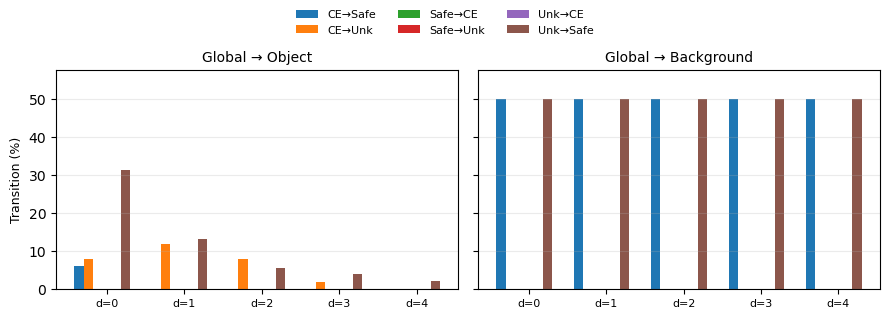

In [5]:
import numpy as np
import matplotlib.pyplot as plt

TRANSITIONS6 = [
    ("CE", "Safe"),
    ("CE", "Unk"),
    ("Safe", "CE"),
    ("Safe", "Unk"),
    ("Unk", "CE"),
    ("Unk", "Safe"),
]

def transition_percent_3(df, A="Global", B="Object"):
    tab = transition_counts_3(df, A, B)

    row_sum = tab.sum(axis=1).replace(0, np.nan)
    pct = tab.div(row_sum, axis=0) * 100.0
    pct = pct.fillna(0.0)

    # keep full 3x3 order
    pct = pct.reindex(index=ORDER3, columns=ORDER3, fill_value=0.0)
    return pct

def compute_6transitions_per_d(DFS, A="Global", B="Object"):
    rows = []
    for label, df_i in DFS:
        pct = transition_percent_3(df_i, A, B)
        row = {"d": label}
        for s, t in TRANSITIONS6:
            row[f"{s}→{t}"] = float(pct.loc[s, t])
        rows.append(row)
    return pd.DataFrame(rows).set_index("d")

def paper_two_panel_plot(DFS, A="Global", out_pdf=None):
    df_obj = compute_6transitions_per_d(DFS, A, "Object")
    df_bg  = compute_6transitions_per_d(DFS, A, "Background")

    # Ensure same column order
    cols = df_obj.columns.tolist()
    df_bg = df_bg.reindex(columns=cols)

    dlabels = df_obj.index.tolist()
    x = np.arange(len(dlabels))
    w = 0.12  # thin bars for paper

    fig, axes = plt.subplots(1, 2, figsize=(9, 3.2), sharey=True)

    ymax = float(max(df_obj.to_numpy().max(), df_bg.to_numpy().max()))
    ylim = max(5, ymax * 1.15)

    # ---------- OBJECT ----------
    ax = axes[0]
    for i, col in enumerate(cols):
        ax.bar(x + (i - len(cols)/2)*w, df_obj[col].values, width=w, label=col)
    ax.set_title("Global → Object", fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels(dlabels, fontsize=8)
    ax.set_ylim(0, ylim)
    ax.grid(axis="y", alpha=0.25)

    # ---------- BACKGROUND ----------
    ax = axes[1]
    for i, col in enumerate(cols):
        ax.bar(x + (i - len(cols)/2)*w, df_bg[col].values, width=w)
    ax.set_title("Global → Background", fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels(dlabels, fontsize=8)
    ax.set_ylim(0, ylim)
    ax.grid(axis="y", alpha=0.25)

    # Shared y-label
    axes[0].set_ylabel("Transition (%)", fontsize=9)

    # Single legend on top
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=3, frameon=False, fontsize=8)

    plt.tight_layout(rect=[0, 0, 1, 0.90])

    if out_pdf:
        plt.savefig(out_pdf, bbox_inches="tight", pad_inches=0.02)

    plt.show()


# Run
paper_two_panel_plot(
    DFS,
    A="Global",
    out_pdf="transitions_object_vs_background_compact.pdf"
)